# Movie Data Analysis

## Install Kaggle API

In [1]:
# Install Kaggle API
!pip install kaggle

# Upload kaggle.json file
from google.colab import files
files.upload()  # Click 'Choose Files' and select your kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vishmalhettigamage","key":"682a501e5934ea0b0856c0e42e982668"}'}

In [2]:
# Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Download the Dataset

In [3]:
# Download the TMDB movies dataset
!kaggle datasets download -d tmdb/tmdb-movie-metadata

# Unzip the downloaded file
!unzip tmdb-movie-metadata.zip

Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
License(s): other
  0% 0.00/8.89M [00:00<?, ?B/s]
100% 8.89M/8.89M [00:00<00:00, 998MB/s]
Archive:  tmdb-movie-metadata.zip
  inflating: tmdb_5000_credits.csv   
  inflating: tmdb_5000_movies.csv    


## Import required libraries

In [4]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

## Load Data and Simplify Genres

In [5]:
# Load the movie dataset
df = pd.read_csv("tmdb_5000_movies.csv")

# Function to extract the first genre from JSON string
def extract_first_genre(genre_str):
    try:
        genres_list = json.loads(genre_str)
        return genres_list[0]['name'] if genres_list else 'Unknown'
    except:
        return 'Unknown'

# Create a new column with simplified genre
df['main_genre'] = df['genres'].apply(extract_first_genre)

# Display first few rows to verify
df[['title', 'main_genre', 'revenue', 'release_date']].head()

,title,main_genre,revenue,release_date
0,Avatar,Action,2787965087,2009-12-10
1,Pirates of the Caribbean: At World's End,Adventure,961000000,2007-05-19
2,Spectre,Action,880674609,2015-10-26
3,The Dark Knight Rises,Action,1084939099,2012-07-16
4,John Carter,Action,284139100,2012-03-07


## Analyze Top Movie Genres

In [6]:
# Count movies by main genre and get top 10
top_genres = df['main_genre'].value_counts().head(10)

# Print the top genres
print("Top 10 Movie Genres:")
print(top_genres)

Top 10 Movie Genres:
main_genre
Drama        1207
Comedy       1042
Action        754
Adventure     339
Horror        300
Crime         195
Thriller      194
Animation     123
Fantasy       117
Romance       106
Name: count, dtype: int64


## Plot Bar Chart of Top Genres

/tmp/ipython-input-2764022004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')


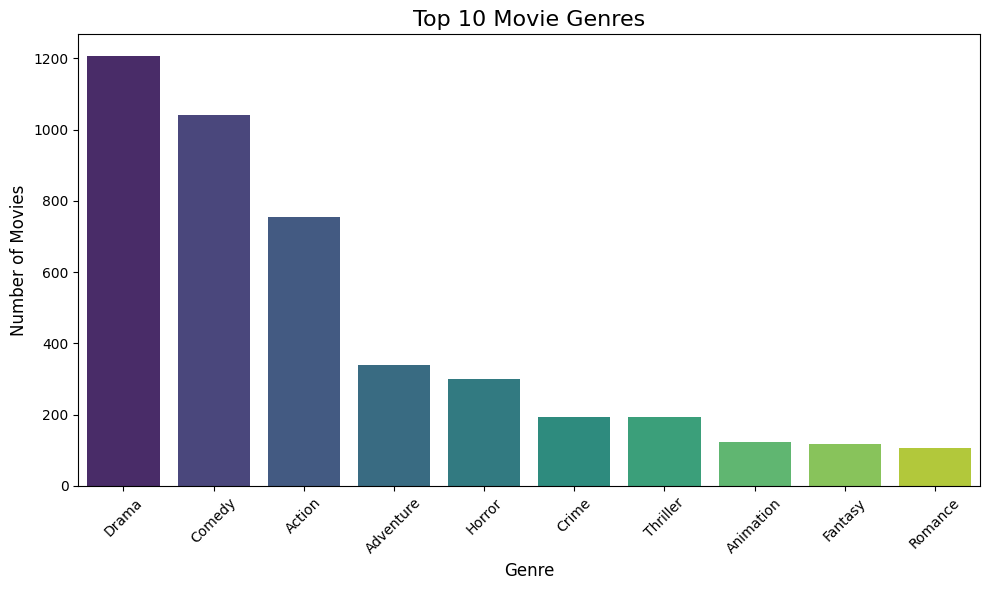

In [7]:
# Plot top genres
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')
plt.title('Top 10 Movie Genres', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyze Revenue Over Time

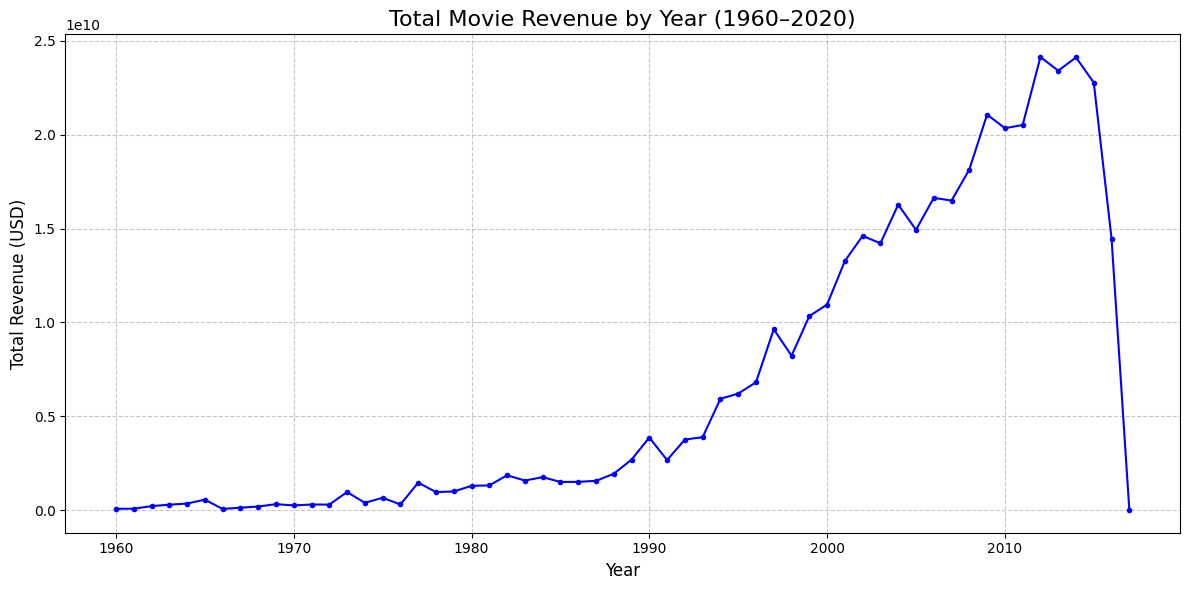

In [8]:
# Extract year from release_date
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Filter data between 1960 and 2020
df_filtered = df[(df['release_year'] >= 1960) & (df['release_year'] <= 2020)]

# Group by year and sum revenue
yearly_revenue = df_filtered.groupby('release_year')['revenue'].sum()

# Plot yearly revenue trend
plt.figure(figsize=(12, 6))
plt.plot(yearly_revenue.index, yearly_revenue.values, color='blue', marker='o', markersize=3)
plt.title('Total Movie Revenue by Year (1960–2020)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## My Findings
- The most popular movie genre: Drama
- Movie revenue increased significantly during the 2010s.
- I learned how to download data from Kaggle, clean JSON-formatted data, and create visualizations.